# GNN 分子性质预测示例（分类BBBP/回归ESOL）+ 不确定度（MC-Dropout）+ 可解释性（IG）

本 Notebook 基于 **PyTorch Geometric (PyG)**，演示：
- **分类**：BBBP（MoleculeNet）
- **回归**：ESOL（MoleculeNet）
- **不确定度**：MC-Dropout；
- **可解释性**：Integrated Gradients 

## 环境与依赖

运行本 Notebook 主要需要以下 Python 包：

- **torch**：PyTorch 深度学习框架
- **torch-geometric**：图神经网络建模与分子图数据处理
- **numpy**：数值计算
- **rdkit**：分子解析、子结构分解与可视化
- **ipython** / **jupyter**：Notebook 显示与交互
- **scikit-learn**：部分分类指标或辅助评估
- **matplotlib**：部分可视化后端支持

# 导入必要的包

In [12]:
# （可选）如果你本地还没装 PyG，请先按官方方式安装：
# https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
# 下面这行仅用于 Notebook 环境快速安装（具体版本需与你的 torch/cuda 匹配）
# !pip install torch_geometric
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_mean_pool
import torch_geometric.transforms as T
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
import copy
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import SVG, display
from torch_geometric.utils.smiles import from_smiles
from rdkit.Chem.Draw import rdMolDraw2D



def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

seed_everything(42)
device = get_device()

## 1) 数据集载入：BBBP（分类） & ESOL（回归）

In [13]:
# =========================================================
# 0. 加载 BBBP 和 ESOL 数据集
# =========================================================
def load_bbbp(root="./data"):
    """
    加载 BBBP 数据集。
    BBBP 是一个二分类数据集，任务通常是预测分子是否具有血脑屏障渗透性。
    
    参数
    ----
    root : str
        数据集保存路径。
    
    返回
    ----
    ds : MoleculeNet
        加载后的 BBBP 数据集对象。
    name : str
        数据集名称字符串。
    """
    ds = MoleculeNet(root=root, name="BBBP")
    return ds, "BBBP"


def load_esol(root="./data"):
    """
    加载 ESOL 数据集。
    ESOL 是一个回归数据集，任务通常是预测分子的水溶解度。
    
    参数
    ----
    root : str
        数据集保存路径。
    
    返回
    ----
    ds : MoleculeNet
        加载后的 ESOL 数据集对象。
    name : str
        数据集名称字符串。
    """
    ds = MoleculeNet(root=root, name="ESOL")
    return ds, "ESOL"


# =========================================================
# 1. 定义原子特征和化学键特征的“解码表”
#    说明：
#    PyG 中的 data.x 和 data.edge_attr 存储的是“索引值”，
#    不是直接可读的化学字符串。
#    因此我们需要借助映射表把它们翻译成人能读懂的含义。
# =========================================================
X_MAP = {
    # 原子序数：0~118
    "atomic_num": list(range(0, 119)),

    # 手性信息
    "chirality": [
        "CHI_UNSPECIFIED",
        "CHI_TETRAHEDRAL_CW",
        "CHI_TETRAHEDRAL_CCW",
        "CHI_OTHER",
        "CHI_TETRAHEDRAL",
        "CHI_ALLENE",
        "CHI_SQUAREPLANAR",
        "CHI_TRIGONALBIPYRAMIDAL",
        "CHI_OCTAHEDRAL",
    ],

    # 原子的度（连接到多少个原子）
    "degree": list(range(0, 11)),

    # 形式电荷
    "formal_charge": list(range(-5, 7)),

    # 氢原子数
    "num_hs": list(range(0, 9)),

    # 自由基电子数
    "num_radical_electrons": list(range(0, 5)),

    # 杂化类型
    "hybridization": [
        "UNSPECIFIED",
        "S",
        "SP",
        "SP2",
        "SP3",
        "SP3D",
        "SP3D2",
        "OTHER",
    ],

    # 是否芳香
    "is_aromatic": [False, True],

    # 是否在环中
    "is_in_ring": [False, True],
}


E_MAP = {
    # 键类型
    "bond_type": [
        "UNSPECIFIED",
        "SINGLE",
        "DOUBLE",
        "TRIPLE",
        "QUADRUPLE",
        "QUINTUPLE",
        "HEXTUPLE",
        "ONEANDAHALF",
        "TWOANDAHALF",
        "THREEANDAHALF",
        "FOURANDAHALF",
        "FIVEANDAHALF",
        "AROMATIC",
        "IONIC",
        "HYDROGEN",
        "THREECENTER",
        "DATIVEONE",
        "DATIVE",
        "DATIVEL",
        "DATIVER",
        "OTHER",
        "ZERO",
    ],

    # 键的立体化学信息
    "stereo": [
        "STEREONONE",
        "STEREOANY",
        "STEREOZ",
        "STEREOE",
        "STEREOCIS",
        "STEREOTRANS",
    ],

    # 是否共轭
    "is_conjugated": [False, True],
}


# =========================================================
# 2. 安全解码函数
#    作用：
#    把一个索引值翻译成对应的标签。
#    例如：
#      1 -> SINGLE
#      12 -> AROMATIC
# =========================================================
def safe_decode(value, candidates):
    """
    把整数索引安全地映射成候选表中的标签。
    
    参数
    ----
    value : int
        某一维特征的索引值。
    candidates : list
        对应特征的候选表。
    
    返回
    ----
    候选表中的具体含义；如果越界，则返回 UNK(值)。
    """
    value = int(value)
    if 0 <= value < len(candidates):
        return candidates[value]
    return f"UNK({value})"


# =========================================================
# 3. 从 MoleculeNet 原始 csv 中读取 SMILES
#    说明：
#    dataset[idx] 返回的是图对象 data；
#    但为了画分子二维图，我们需要原始的 SMILES 字符串。
# =========================================================
def get_smiles_from_raw_csv(dataset, idx=0):
    """
    从 MoleculeNet 的原始 csv 文件中读取第 idx 个样本的 SMILES。
    
    参数
    ----
    dataset : MoleculeNet
        已加载的数据集对象。
    idx : int
        样本编号。
    
    返回
    ----
    smiles : str
        对应样本的 SMILES 字符串。
    """
    raw_path = dataset.raw_paths[0]
    df = pd.read_csv(raw_path)

    smiles_col = None
    for col in df.columns:
        if "smiles" in col.lower():
            smiles_col = col
            break

    if smiles_col is None:
        raise ValueError(f"在 {raw_path} 中没有找到 smiles 列")

    return df.iloc[idx][smiles_col]


# =========================================================
# 4. 画分子的二维结构图，并在图上标出原子编号
#    说明：
#    这里使用 RDKit 将 SMILES 转成二维结构，并给每个原子打上序号。
# =========================================================
def draw_molecule_with_atom_indices(smiles, size=(700, 450)):
    """
    根据 SMILES 画出二维分子结构图，并在图上显示原子编号。
    
    参数
    ----
    smiles : str
        分子的 SMILES 表示。
    size : tuple
        图片尺寸，格式为 (宽, 高)。
    
    返回
    ----
    mol : rdkit.Chem.Mol
        RDKit 分子对象，便于后续读取原子符号等信息。
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"SMILES 无法解析: {smiles}")

    # 生成二维坐标
    rdDepictor.Compute2DCoords(mol)

    # 给每个原子加上可显示的编号
    for atom in mol.GetAtoms():
        atom.SetProp("atomNote", str(atom.GetIdx()))

    # 使用 SVG 方式绘图，更适合 Notebook 显示
    drawer = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
    drawer.FinishDrawing()

    svg = drawer.GetDrawingText()
    display(SVG(svg))

    return mol


# =========================================================
# 5. 解码节点特征（直接读取 data.x）
#    说明：
#    data.x 的每一行对应一个原子，每一列对应一个离散特征。
#    我们把它翻译成更容易看懂的表格。
# =========================================================
def decode_node_features(data, mol):
    """
    将 data.x 中的原子节点特征解码为可读表格。
    
    参数
    ----
    data : torch_geometric.data.Data
        图数据对象，包含 x, edge_index, edge_attr, y 等信息。
    mol : rdkit.Chem.Mol
        RDKit 分子对象，用于获取原子符号。
    
    返回
    ----
    node_df : pandas.DataFrame
        节点特征解码后的表格。
    """
    rows = []

    # 遍历每一个原子节点
    for i in range(data.num_nodes):
        x = data.x[i].tolist()           # 当前原子的原始特征向量
        atom = mol.GetAtomWithIdx(i)     # RDKit 中对应的原子对象

        rows.append({
            "原子编号": i,
            "原子符号": atom.GetSymbol(),

            # 原始索引向量
            "原始节点特征": x,

            # 逐维解码后的中文含义
            "原子序数": safe_decode(x[0], X_MAP["atomic_num"]),
            "手性": safe_decode(x[1], X_MAP["chirality"]),
            "度": safe_decode(x[2], X_MAP["degree"]),
            "形式电荷": safe_decode(x[3], X_MAP["formal_charge"]),
            "氢原子数": safe_decode(x[4], X_MAP["num_hs"]),
            "自由基电子数": safe_decode(x[5], X_MAP["num_radical_electrons"]),
            "杂化方式": safe_decode(x[6], X_MAP["hybridization"]),
            "是否芳香": safe_decode(x[7], X_MAP["is_aromatic"]),
            "是否在环中": safe_decode(x[8], X_MAP["is_in_ring"]),
        })

    return pd.DataFrame(rows)


# =========================================================
# 6. 解码边特征（直接读取 data.edge_index 和 data.edge_attr）
#    说明：
#    PyG 中一条无向边通常会存成两个方向：
#      i -> j
#      j -> i
#    为了更方便教学展示，这里默认只保留无向边的一份。
# =========================================================
def decode_edge_features(data, mol, unique_undirected=True):
    """
    将 data.edge_index 和 data.edge_attr 解码为可读表格。
    
    参数
    ----
    data : torch_geometric.data.Data
        图数据对象。
    mol : rdkit.Chem.Mol
        RDKit 分子对象。
    unique_undirected : bool
        是否只保留无向边的一份。
        若为 True，则 (i,j) 和 (j,i) 只显示一次。
    
    返回
    ----
    edge_df : pandas.DataFrame
        边特征解码后的表格。
    """
    rows = []
    seen = set()

    edge_attr = getattr(data, "edge_attr", None)

    # 遍历每一条边
    for e in range(data.edge_index.shape[1]):
        src = int(data.edge_index[0, e])   # 起点原子编号
        dst = int(data.edge_index[1, e])   # 终点原子编号

        # 如果只展示无向边的一份，则对 (src, dst) 排序后去重
        if unique_undirected:
            key = tuple(sorted((src, dst)))
            if key in seen:
                continue
            seen.add(key)

        src_atom = mol.GetAtomWithIdx(src)
        dst_atom = mol.GetAtomWithIdx(dst)

        row = {
            "起点原子编号": src,
            "起点原子符号": src_atom.GetSymbol(),
            "终点原子编号": dst,
            "终点原子符号": dst_atom.GetSymbol(),
        }

        # 如果存在边特征，则进行解码
        if edge_attr is not None:
            ef = data.edge_attr[e].tolist()

            row["原始边特征"] = ef
            row["键类型"] = safe_decode(ef[0], E_MAP["bond_type"])
            row["立体信息"] = safe_decode(ef[1], E_MAP["stereo"])
            row["是否共轭"] = safe_decode(ef[2], E_MAP["is_conjugated"])
        else:
            row["原始边特征"] = None
            row["键类型"] = None
            row["立体信息"] = None
            row["是否共轭"] = None

        rows.append(row)

    return pd.DataFrame(rows)


# =========================================================
# 7. 主展示函数
#    作用：
#    让学生输入一个分子编号 idx，就能看到：
#    1) SMILES
#    2) 2D 结构图（带原子编号）
#    3) 图级张量信息
#    4) 节点特征解码表
#    5) 边特征解码表
#    6) 原始 edge_index 和 edge_attr
# =========================================================
def show_molecule_data(dataset, dataset_name, idx=0, unique_undirected=True):
    """
    展示指定编号分子的完整图表示信息。
    
    参数
    ----
    dataset : MoleculeNet
        已加载的数据集对象。
    dataset_name : str
        数据集名称。
    idx : int
        要查看的分子编号。
    unique_undirected : bool
        是否只保留无向边的一份。
    """
    # 取出第 idx 个图数据对象
    data = dataset[idx]

    # 从原始 csv 中取出该分子的 SMILES
    smiles = get_smiles_from_raw_csv(dataset, idx)

    print("=" * 100)
    print(f"数据集名称: {dataset_name}")
    print(f"样本编号: {idx}")
    print(f"SMILES: {smiles}")
    print(f"标签 y: {data.y}")
    print("=" * 100)

    # -----------------------------------------------------
    # [1] 显示带原子编号的 2D 分子结构图
    # -----------------------------------------------------
    print("\n[1] 带原子编号的二维分子结构图")
    mol = draw_molecule_with_atom_indices(smiles)

    # -----------------------------------------------------
    # [2] 显示图级信息
    # -----------------------------------------------------
    print("\n[2] 图级张量信息")
    print(f"节点数 num_nodes: {data.num_nodes}")
    print(f"边数 num_edges（注意：PyG 中通常是有向边数）: {data.num_edges}")
    print(f"节点特征矩阵 x 的形状: {tuple(data.x.shape)}")
    print(f"边索引 edge_index 的形状: {tuple(data.edge_index.shape)}")

    if getattr(data, "edge_attr", None) is not None:
        print(f"边特征矩阵 edge_attr 的形状: {tuple(data.edge_attr.shape)}")
    else:
        print("该图没有 edge_attr")

    # -----------------------------------------------------
    # [3] 解码节点特征
    # -----------------------------------------------------
    print("\n[3] 节点特征解码表")
    node_df = decode_node_features(data, mol)
    display(node_df)

    # -----------------------------------------------------
    # [4] 解码边特征
    # -----------------------------------------------------
    print("\n[4] 边特征解码表（含连接关系）")
    edge_df = decode_edge_features(data, mol, unique_undirected=unique_undirected)
    display(edge_df)

    # -----------------------------------------------------
    # [5] 原始 edge_index
    # -----------------------------------------------------
    print("\n[5] 数据集中的原始 edge_index")
    print(data.edge_index)

    # -----------------------------------------------------
    # [6] 原始 edge_attr
    # -----------------------------------------------------
    if getattr(data, "edge_attr", None) is not None:
        print("\n[6] 数据集中的原始 edge_attr")
        print(data.edge_attr)

    print("=" * 100)


# =========================================================
# 8. 加载数据集并打印基本信息
# =========================================================
ds_cls, cls_name = load_bbbp("./data")
ds_reg, reg_name = load_esol("./data")

print(
    "分类数据集:", cls_name,
    "| 分子总数:", len(ds_cls),
    "| 节点特征维度:", ds_cls.num_features,
    "| 单个样本标签形状:", ds_cls[0].y.shape
)

print(
    "回归数据集:", reg_name,
    "| 分子总数:", len(ds_reg),
    "| 节点特征维度:", ds_reg.num_features,
    "| 单个样本标签形状:", ds_reg[0].y.shape
)

分类数据集: BBBP | 分子总数: 2039 | 节点特征维度: 9 | 单个样本标签形状: torch.Size([1, 1])
回归数据集: ESOL | 分子总数: 1128 | 节点特征维度: 9 | 单个样本标签形状: torch.Size([1, 1])


## 查看具体分子信息，节点特征，边特征

数据集名称: BBBP
样本编号: 10
SMILES: OCC(C)(O)c1onc(c2ncn3c2CN(C)C(c4c3cccc4Cl)=O)n1
标签 y: tensor([[0.]])

[1] 带原子编号的二维分子结构图


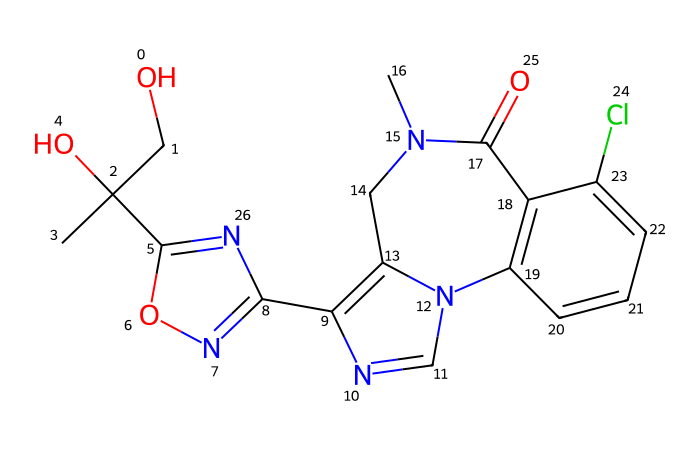


[2] 图级张量信息
节点数 num_nodes: 27
边数 num_edges（注意：PyG 中通常是有向边数）: 60
节点特征矩阵 x 的形状: (27, 9)
边索引 edge_index 的形状: (2, 60)
边特征矩阵 edge_attr 的形状: (60, 3)

[3] 节点特征解码表


,原子编号,原子符号,原始节点特征,原子序数,手性,度,形式电荷,氢原子数,自由基电子数,杂化方式,是否芳香,是否在环中
0,0,O,"[8, 0, 2, 5, 1, 0, 4, 0, 0]",8,CHI_UNSPECIFIED,2,0,1,0,SP3,False,False
1,1,C,"[6, 0, 4, 5, 2, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,2,0,SP3,False,False
2,2,C,"[6, 0, 4, 5, 0, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,0,0,SP3,False,False
3,3,C,"[6, 0, 4, 5, 3, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,3,0,SP3,False,False
4,4,O,"[8, 0, 2, 5, 1, 0, 4, 0, 0]",8,CHI_UNSPECIFIED,2,0,1,0,SP3,False,False
5,5,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
6,6,O,"[8, 0, 2, 5, 0, 0, 3, 1, 1]",8,CHI_UNSPECIFIED,2,0,0,0,SP2,True,True
7,7,N,"[7, 0, 2, 5, 0, 0, 3, 1, 1]",7,CHI_UNSPECIFIED,2,0,0,0,SP2,True,True
8,8,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
9,9,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True



[4] 边特征解码表（含连接关系）


,起点原子编号,起点原子符号,终点原子编号,终点原子符号,原始边特征,键类型,立体信息,是否共轭
0,0,O,1,C,"[1, 0, 0]",SINGLE,STEREONONE,False
1,1,C,2,C,"[1, 0, 0]",SINGLE,STEREONONE,False
2,2,C,3,C,"[1, 0, 0]",SINGLE,STEREONONE,False
3,2,C,4,O,"[1, 0, 0]",SINGLE,STEREONONE,False
4,2,C,5,C,"[1, 0, 0]",SINGLE,STEREONONE,False
5,5,C,6,O,"[12, 0, 1]",AROMATIC,STEREONONE,True
6,5,C,26,N,"[12, 0, 1]",AROMATIC,STEREONONE,True
7,6,O,7,N,"[12, 0, 1]",AROMATIC,STEREONONE,True
8,7,N,8,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
9,8,C,9,C,"[1, 0, 1]",SINGLE,STEREONONE,True



[5] 数据集中的原始 edge_index
tensor([[ 0,  1,  1,  2,  2,  2,  2,  3,  4,  5,  5,  5,  6,  6,  7,  7,  8,  8,
          8,  9,  9,  9, 10, 10, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 15, 15,
         15, 16, 17, 17, 17, 18, 18, 18, 19, 19, 19, 20, 20, 21, 21, 22, 22, 23,
         23, 23, 24, 25, 26, 26],
        [ 1,  0,  2,  1,  3,  4,  5,  2,  2,  2,  6, 26,  5,  7,  6,  8,  7,  9,
         26,  8, 10, 13,  9, 11, 10, 12, 11, 13, 19,  9, 12, 14, 13, 15, 14, 16,
         17, 15, 15, 18, 25, 17, 19, 23, 12, 18, 20, 19, 21, 20, 22, 21, 23, 18,
         22, 24, 23, 17,  5,  8]])

[6] 数据集中的原始 edge_attr
tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [ 1,  0,  1],
  

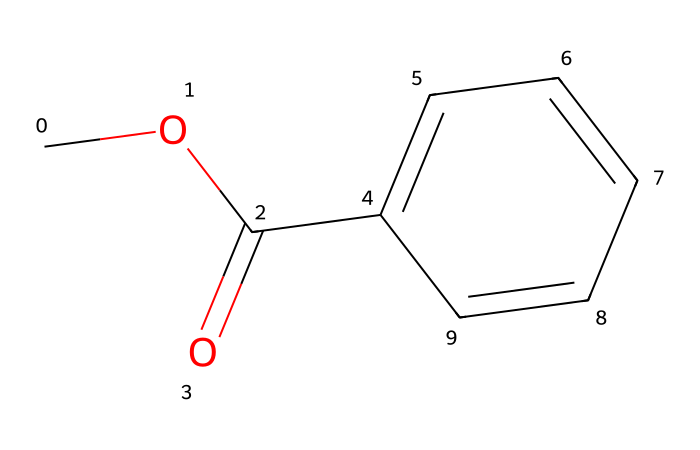


[2] 图级张量信息
节点数 num_nodes: 10
边数 num_edges（注意：PyG 中通常是有向边数）: 20
节点特征矩阵 x 的形状: (10, 9)
边索引 edge_index 的形状: (2, 20)
边特征矩阵 edge_attr 的形状: (20, 3)

[3] 节点特征解码表


,原子编号,原子符号,原始节点特征,原子序数,手性,度,形式电荷,氢原子数,自由基电子数,杂化方式,是否芳香,是否在环中
0,0,C,"[6, 0, 4, 5, 3, 0, 4, 0, 0]",6,CHI_UNSPECIFIED,4,0,3,0,SP3,False,False
1,1,O,"[8, 0, 2, 5, 0, 0, 3, 0, 0]",8,CHI_UNSPECIFIED,2,0,0,0,SP2,False,False
2,2,C,"[6, 0, 3, 5, 0, 0, 3, 0, 0]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,False,False
3,3,O,"[8, 0, 1, 5, 0, 0, 3, 0, 0]",8,CHI_UNSPECIFIED,1,0,0,0,SP2,False,False
4,4,C,"[6, 0, 3, 5, 0, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,0,0,SP2,True,True
5,5,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
6,6,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
7,7,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
8,8,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True
9,9,C,"[6, 0, 3, 5, 1, 0, 3, 1, 1]",6,CHI_UNSPECIFIED,3,0,1,0,SP2,True,True



[4] 边特征解码表（含连接关系）


,起点原子编号,起点原子符号,终点原子编号,终点原子符号,原始边特征,键类型,立体信息,是否共轭
0,0,C,1,O,"[1, 0, 0]",SINGLE,STEREONONE,False
1,1,O,2,C,"[1, 0, 1]",SINGLE,STEREONONE,True
2,2,C,3,O,"[2, 0, 1]",DOUBLE,STEREONONE,True
3,2,C,4,C,"[1, 0, 1]",SINGLE,STEREONONE,True
4,4,C,5,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
5,4,C,9,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
6,5,C,6,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
7,6,C,7,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
8,7,C,8,C,"[12, 0, 1]",AROMATIC,STEREONONE,True
9,8,C,9,C,"[12, 0, 1]",AROMATIC,STEREONONE,True



[5] 数据集中的原始 edge_index
tensor([[0, 1, 1, 2, 2, 2, 3, 4, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9],
        [1, 0, 2, 1, 3, 4, 2, 2, 5, 9, 4, 6, 5, 7, 6, 8, 7, 9, 4, 8]])

[6] 数据集中的原始 edge_attr
tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  1],
        [ 1,  0,  1],
        [ 2,  0,  1],
        [ 1,  0,  1],
        [ 2,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1]])


In [14]:
# =========================================================
# 10. 示例：查看一个 BBBP 分子
# =========================================================
show_molecule_data(ds_cls, cls_name, idx=10, unique_undirected=True)


# =========================================================
# 11. 示例：查看一个 ESOL 分子
# =========================================================
show_molecule_data(ds_reg, reg_name, idx=726, unique_undirected=True)

## 2) 通用代码：GIN 模型（分类/回归）+  训练/评估

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool, global_add_pool
import torch
from torch.utils.data import random_split

def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集按 train / val / test 划分
    默认比例：8 : 1 : 1
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


class MLP(nn.Module):
    """两层感知机：用于分类头或回归头"""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),   # 线性映射到隐藏空间
            nn.ReLU(),                       # 非线性激活
            nn.Dropout(dropout),             # dropout 正则化
            nn.Linear(hidden_dim, out_dim),  # 输出层
        )

    def forward(self, x):
        return self.net(x)


class GINBackbone(nn.Module):
    """GIN 主干网络：输入图，输出图级 embedding"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()         # 存放多层 GINConv
        self.bns = nn.ModuleList()           # 存放每层 BatchNorm

        for i in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),  # 第1层输入维度为 in_dim，其余层为 hidden_dim
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))          # GINConv：邻居聚合 + MLP 更新
            self.bns.append(nn.BatchNorm1d(hidden_dim))

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)                  # 节点消息传递
            x = bn(x)                                # 批标准化
            x = F.relu(x)                            # 非线性激活
            x = F.dropout(x, p=self.dropout, training=self.training)

        g = global_mean_pool(x, batch)               # 节点表示平均池化为图表示
        return g


class GINClassifier(nn.Module):
    """GIN 二分类模型：输出 2 维 logits"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 2, dropout)              # 分类头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g)                                # logits [B, 2]


class GINRegressor(nn.Module):
    """GIN 回归模型：输出 1 个连续值"""
    def __init__(self, in_dim, hidden_dim=128, num_layers=4, dropout=0.2):
        super().__init__()
        self.gnn = GINBackbone(in_dim, hidden_dim, num_layers, dropout)  # 图神经网络主干
        self.head = MLP(hidden_dim, hidden_dim, 1, dropout)              # 回归头

    def forward(self, data):
        g = self.gnn(data.x, data.edge_index, data.batch)  # 图级 embedding
        return self.head(g).view(-1)                       # [B, 1] -> [B]


class GINMaskRegressor(nn.Module):
    """支持 pooling-mask 的回归模型：拆分为节点编码和图读出两步"""
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.x_proj = nn.Linear(in_dim, hidden_dim)  # 输入特征先映射到 hidden_dim

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp, train_eps=True))  # train_eps=True：epsilon 参数可学习
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),   # 回归输出
        )

    def encode_nodes(self, data):
        """节点编码阶段：输出每个节点的 embedding"""
        x = data.x.float()
        h = self.x_proj(x)

        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, data.edge_index)               # 节点消息传递
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        return h                                      # [N, hidden_dim]

    def readout(self, h, batch, node_keep_mask=None):
        """图读出阶段：支持在 pooling 时屏蔽部分节点"""
        if node_keep_mask is not None:
            h = h * node_keep_mask.view(-1, 1).to(h.dtype)  # 被屏蔽节点贡献置零

        g = global_add_pool(h, batch)                 # 节点表示求和为图表示
        out = self.head(g).view(-1)                   # 图级回归输出
        return out

    def forward(self, data, node_keep_mask=None):
        if not hasattr(data, "batch") or data.batch is None:
            data.batch = torch.zeros(
                data.num_nodes,
                dtype=torch.long,
                device=data.x.device
            )                                         # 单图时手动补 batch

        h = self.encode_nodes(data)                   # 节点编码
        out = self.readout(h, data.batch, node_keep_mask=node_keep_mask)  # 图读出
        return out


@torch.no_grad()
def eval_classification(model, loader, device):
    """分类评估：返回 accuracy"""
    model.eval()
    correct, total = 0, 0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 分类 logits
        pred = logits.argmax(dim=-1)                  # 预测类别
        y = batch.y.view(-1).long()                   # 真实标签
        correct += int((pred == y).sum())
        total += y.numel()

    return correct / max(total, 1)


@torch.no_grad()
def eval_regression(model, loader, device):
    """回归评估：返回 RMSE 和 MAE"""
    model.eval()
    ys, ps = [], []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                           # 预测值
        y = batch.y.view(-1).float()                  # 真实值
        ys.append(y.detach().cpu())
        ps.append(pred.detach().cpu())

    y = torch.cat(ys)
    p = torch.cat(ps)

    rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()   # 均方根误差
    mae = torch.mean(torch.abs(p - y)).item()            # 平均绝对误差
    return rmse, mae


def train_one_epoch_classification(model, loader, opt, device):
    """分类任务训练一个 epoch：返回平均交叉熵损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)                         # 前向传播
        y = batch.y.view(-1).long()                  # 真实标签
        loss = F.cross_entropy(logits, y)            # 交叉熵损失

        opt.zero_grad()
        loss.backward()                              # 反向传播
        opt.step()

        total_loss += loss.detach().item() * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)


def train_one_epoch_regression(model, loader, opt, device):
    """回归任务训练一个 epoch：返回平均 MSE 损失"""
    model.train()
    total_loss = 0.0

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)                          # 前向传播
        y = batch.y.view(-1).float()                 # 真实值
        loss = F.mse_loss(pred, y)                   # 均方误差损失

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.detach().item() * y.size(0)        # 按样本数累计损失

    return total_loss / max(len(loader.dataset), 1)
print("训练代码载入完成！")

训练代码载入完成！


## 3) 任务A：BBBP 分类训练

In [19]:
import os
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

# =========================
# 0. 超参数设置区域（学生主要修改这里）
# =========================
HP = {
    "seed": 42,                  # 随机种子
    "batch_size_train": 64,      # 训练集 batch size
    "batch_size_eval": 256,      # 验证/测试 batch size
    "hidden_dim": 128,           # 隐藏层维度
    "num_layers": 4,             # GINConv 层数
    "dropout": 0.2,              # dropout 概率
    "lr": 1e-3,                  # 学习率
    "weight_decay": 1e-5,        # L2 正则
    "epochs": 100,               # 训练轮数
    "model_dir": "saved_models"  # 模型保存目录
}

# =========================
# 1. 打印当前超参数
# =========================
param_name_map = {
    "seed": "随机种子",
    "batch_size_train": "训练集批大小",
    "batch_size_eval": "验证/测试批大小",
    "hidden_dim": "隐藏层维度",
    "num_layers": "网络层数",
    "dropout": "Dropout 概率",
    "lr": "学习率",
    "weight_decay": "权重衰减",
    "epochs": "训练轮数",
    "model_dir": "模型保存目录"
}

print("当前实验超参数：")
for k, v in HP.items():
    print(f"{param_name_map.get(k, k)}: {v}")


# =========================
# 2. 工具函数
# =========================
def make_model_name(task_name="gin_cls", hp=None):
    """
    根据超参数自动生成模型文件名，便于比较不同实验结果
    """
    name = (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs{hp['batch_size_train']}"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )
    return name


def build_subset_with_ids(subset):
    """
    将 Subset 转成新的样本列表，并补充：
    - dataset_id：在原始完整数据集中的编号
    - subset_id ：在当前子集中的编号

    便于后续保存预测结果并回查原始分子。
    """
    if hasattr(subset, "indices"):
        base_dataset = subset.dataset
        indices = list(subset.indices)
    else:
        base_dataset = subset
        indices = list(range(len(subset)))

    new_data_list = []
    for subset_id, dataset_id in enumerate(indices):
        data = copy.deepcopy(base_dataset[dataset_id])
        data.dataset_id = torch.tensor([dataset_id], dtype=torch.long)
        data.subset_id = torch.tensor([subset_id], dtype=torch.long)
        new_data_list.append(data)

    return new_data_list


@torch.no_grad()
def eval_classification_with_details(model, loader, device, full_dataset=None):
    """
    评估分类模型，并保留每个样本的详细预测结果。

    返回：
    - acc
    - pred_df：DataFrame，包含每个样本的详细预测信息
    """
    model.eval()
    rows = []

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)                    # [B, C]
        probs = torch.softmax(logits, dim=-1)   # [B, C]
        preds = logits.argmax(dim=-1)           # [B]
        y = batch.y.view(-1).long()             # [B]

        probs_np = probs.detach().cpu().numpy()
        preds_np = preds.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        dataset_ids = batch.dataset_id.view(-1).detach().cpu().numpy()
        subset_ids = batch.subset_id.view(-1).detach().cpu().numpy()

        num_classes = probs_np.shape[1]

        for i in range(len(y_np)):
            row = {
                "dataset_id": int(dataset_ids[i]),             # 原始完整数据集中的编号
                "true_label": int(y_np[i]),                   # 真实类别
                "pred_label": int(preds_np[i]),               # 预测类别
                "correct": int(preds_np[i] == y_np[i]),       # 是否预测正确
            }

            # 如果是二分类，额外补一个正类概率，便于后续分析
            if num_classes == 2:
                row["pred_prob_pos"] = float(probs_np[i, 1])

            # 如果原始数据集中带有 smiles 字段，就顺手补上
            if full_dataset is not None and hasattr(full_dataset[int(dataset_ids[i])], "smiles"):
                row["smiles"] = full_dataset[int(dataset_ids[i])].smiles

            rows.append(row)

    pred_df = pd.DataFrame(rows)
    acc = pred_df["correct"].mean()

    return acc, pred_df


# =========================
# 3. 数据集划分与加载
# =========================
train_set_raw, val_set_raw, test_set_raw = split_dataset(ds_cls, seed=HP["seed"])  # 按固定随机种子划分

# 训练集直接使用原始子集即可
train_loader = DataLoader(
    train_set_raw,
    batch_size=HP["batch_size_train"],
    shuffle=True
)

# 验证集、测试集补充 dataset_id / subset_id，便于保存预测结果
val_set = build_subset_with_ids(val_set_raw)
test_set = build_subset_with_ids(test_set_raw)

val_loader = DataLoader(
    val_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)
test_loader = DataLoader(
    test_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)


# =========================
# 4. 模型构建
# =========================
model_cls = GINClassifier(
    in_dim=ds_cls.num_features,         # 节点输入特征维度
    hidden_dim=HP["hidden_dim"],        # 隐藏层维度
    num_layers=HP["num_layers"],        # GINConv 层数
    dropout=HP["dropout"]               # dropout 概率
).to(device)


# =========================
# 5. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_cls.parameters(),
    lr=HP["lr"],
    weight_decay=HP["weight_decay"]
)


# =========================
# 6. 训练过程
# =========================
best_val = 0.0
best_state = None

print("\n开始训练分类模型...")
train_start_time = time.time()   # 记录总训练开始时间

for epoch in range(1, HP["epochs"] + 1):
    epoch_start_time = time.time()   # 记录当前 epoch 开始时间

    loss = train_one_epoch_classification(
        model_cls, train_loader, opt, device
    )

    val_acc = eval_classification(
        model_cls, val_loader, device
    )

    # 若当前验证集性能更好，则保存最优参数
    if val_acc > best_val:
        best_val = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_cls.state_dict().items()
        }

    epoch_time = time.time() - epoch_start_time         # 当前 epoch 用时
    total_time = time.time() - train_start_time         # 累计训练用时

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"第 {epoch:03d} 轮 | "
            f"训练损失 = {loss:.4f} | "
            f"验证集准确率 = {val_acc:.4f} | "
            f"本轮耗时 = {epoch_time:.2f} 秒 | "
            f"累计耗时 = {total_time:.2f} 秒"
        )


# =========================
# 7. 恢复最佳模型
# =========================
if best_state is not None:
    model_cls.load_state_dict(best_state)

total_train_time = time.time() - train_start_time
print(f"\n训练完成，总耗时：{total_train_time:.2f} 秒")


# =========================
# 8. 测试集评估，并保留预测结果
# =========================
test_acc, test_pred_df = eval_classification_with_details(
    model_cls,
    test_loader,
    device,
    full_dataset=ds_cls
)

print(f"最佳验证集准确率 = {best_val:.4f}")
print(f"测试集准确率     = {test_acc:.4f}")

print("\n测试集部分预测结果（前 10 条）：")
print(test_pred_df.head(10).to_string(index=False))


# =========================
# 9. 可选：也保留验证集预测结果
# =========================
val_acc_best, val_pred_df = eval_classification_with_details(
    model_cls,
    val_loader,
    device,
    full_dataset=ds_cls
)

print("\n验证集部分预测结果（前 5 条）：")
print(val_pred_df.head(5).to_string(index=False))


# =========================
# 10. 保存模型（文件名包含超参数）
# =========================
Path(HP["model_dir"]).mkdir(parents=True, exist_ok=True)

save_name = make_model_name(task_name="gin_cls", hp=HP)
save_path = os.path.join(HP["model_dir"], save_name)

torch.save({
    "model_state_dict": model_cls.state_dict(),  # 最优模型参数
}, save_path)

print(f"\n模型已保存到：{save_path}")


# =========================
# 11. 额外保存预测结果，便于后续分析
# =========================
test_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_测试集预测结果.csv")
)
val_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_验证集预测结果.csv")
)

test_pred_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")
val_pred_df.to_csv(val_pred_path, index=False, encoding="utf-8-sig")

print(f"测试集预测结果已保存到：{test_pred_path}")
print(f"验证集预测结果已保存到：{val_pred_path}")

当前实验超参数：
随机种子: 42
训练集批大小: 64
验证/测试批大小: 256
隐藏层维度: 128
网络层数: 4
Dropout 概率: 0.2
学习率: 0.001
权重衰减: 1e-05
训练轮数: 100
模型保存目录: saved_models

开始训练分类模型...
第 001 轮 | 训练损失 = 0.4843 | 验证集准确率 = 0.5961 | 本轮耗时 = 0.24 秒 | 累计耗时 = 0.24 秒
第 010 轮 | 训练损失 = 0.3388 | 验证集准确率 = 0.7980 | 本轮耗时 = 0.20 秒 | 累计耗时 = 2.09 秒
第 020 轮 | 训练损失 = 0.2854 | 验证集准确率 = 0.7980 | 本轮耗时 = 0.19 秒 | 累计耗时 = 4.04 秒
第 030 轮 | 训练损失 = 0.2672 | 验证集准确率 = 0.7094 | 本轮耗时 = 0.20 秒 | 累计耗时 = 6.15 秒
第 040 轮 | 训练损失 = 0.2513 | 验证集准确率 = 0.7931 | 本轮耗时 = 0.20 秒 | 累计耗时 = 8.18 秒
第 050 轮 | 训练损失 = 0.2187 | 验证集准确率 = 0.8522 | 本轮耗时 = 0.20 秒 | 累计耗时 = 10.30 秒
第 060 轮 | 训练损失 = 0.1953 | 验证集准确率 = 0.8424 | 本轮耗时 = 0.20 秒 | 累计耗时 = 12.38 秒
第 070 轮 | 训练损失 = 0.2059 | 验证集准确率 = 0.8374 | 本轮耗时 = 0.19 秒 | 累计耗时 = 14.44 秒
第 080 轮 | 训练损失 = 0.1682 | 验证集准确率 = 0.8325 | 本轮耗时 = 0.22 秒 | 累计耗时 = 16.44 秒
第 090 轮 | 训练损失 = 0.1558 | 验证集准确率 = 0.8522 | 本轮耗时 = 0.21 秒 | 累计耗时 = 18.53 秒
第 100 轮 | 训练损失 = 0.1530 | 验证集准确率 = 0.8325 | 本轮耗时 = 0.20 秒 | 累计耗时 = 20.55 秒

训练完成，总耗时：20.55 秒
最佳验证集准确率 = 0.8670

## 4) 任务B：ESOL 回归训练

In [20]:
import os
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader

# =========================
# 0. 超参数设置区域（主要修改这里）
# =========================
HP = {
    "seed": 42,                  # 随机种子
    "batch_size_train": 64,      # 训练集 batch size
    "batch_size_eval": 256,      # 验证/测试 batch size
    "hidden_dim": 128,           # 隐藏层维度
    "num_layers": 4,             # GINConv 层数
    "dropout": 0.2,              # dropout 概率
    "lr": 1e-3,                  # 学习率
    "weight_decay": 1e-5,        # L2 正则
    "epochs": 100,               # 训练轮数
    "model_dir": "saved_models", # 模型保存目录
    "task_name": "gin_reg"       # 任务名称
}

# =========================
# 1. 打印当前超参数
# =========================
param_name_map = {
    "seed": "随机种子",
    "batch_size_train": "训练集批大小",
    "batch_size_eval": "验证/测试批大小",
    "hidden_dim": "隐藏层维度",
    "num_layers": "网络层数",
    "dropout": "Dropout 概率",
    "lr": "学习率",
    "weight_decay": "权重衰减",
    "epochs": "训练轮数",
    "model_dir": "模型保存目录",
    "task_name": "任务名称"
}

print("当前实验超参数：")
for k, v in HP.items():
    print(f"{param_name_map.get(k, k)}: {v}")


# =========================
# 2. 数据集划分函数
# =========================
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集划分为训练集 / 验证集 / 测试集
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


# =========================
# 3. 生成模型保存文件名
# =========================
def make_model_name(task_name="gin_reg", hp=None):
    name = (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs{hp['batch_size_train']}"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )
    return name


# =========================
# 4. 给验证/测试子集补充索引信息
# =========================
def build_subset_with_ids(subset):
    """
    将 Subset 转成一个新的样本列表，并为每个样本补充：
    - dataset_id：在原始完整数据集中的编号
    - subset_id ：在当前子集中的编号

    这样在保存预测结果时，便于回查原始分子。
    """
    if hasattr(subset, "indices"):
        base_dataset = subset.dataset
        indices = list(subset.indices)
    else:
        base_dataset = subset
        indices = list(range(len(subset)))

    new_data_list = []
    for subset_id, dataset_id in enumerate(indices):
        data = copy.deepcopy(base_dataset[dataset_id])
        data.dataset_id = torch.tensor([dataset_id], dtype=torch.long)
        data.subset_id = torch.tensor([subset_id], dtype=torch.long)
        new_data_list.append(data)

    return new_data_list


# =========================
# 5. 训练一个 epoch
# =========================
def train_one_epoch_regression(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        loss = torch.nn.functional.mse_loss(pred, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * y.size(0)
        total_samples += y.size(0)

    return total_loss / total_samples


# =========================
# 6. 回归评估：仅返回指标
# =========================
@torch.no_grad()
def eval_regression(model, loader, device):
    model.eval()
    preds_all = []
    trues_all = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        preds_all.append(pred.detach().cpu())
        trues_all.append(y.detach().cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    trues_all = torch.cat(trues_all, dim=0).numpy()

    rmse = np.sqrt(((preds_all - trues_all) ** 2).mean())
    mae = np.abs(preds_all - trues_all).mean()
    return rmse, mae


# =========================
# 7. 回归评估：返回详细预测结果
# =========================
@torch.no_grad()
def eval_regression_with_details(model, loader, device, full_dataset=None):
    """
    在评估时同时保留每个样本的预测结果，便于后续分析。

    返回：
    - rmse
    - mae
    - pred_df：DataFrame，包含每个样本的详细预测信息
    """
    model.eval()
    rows = []

    for batch in loader:
        batch = batch.to(device)

        pred = model(batch).view(-1)
        y = batch.y.view(-1).float()

        pred_np = pred.detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        dataset_ids = batch.dataset_id.view(-1).detach().cpu().numpy()
        subset_ids = batch.subset_id.view(-1).detach().cpu().numpy()

        for i in range(len(y_np)):
            row = {
                "dataset_id": int(dataset_ids[i]),     # 原始完整数据集中的编号
                "true_value": float(y_np[i]),          # 真实值
                "pred_value": float(pred_np[i]),       # 预测值
                "abs_error": float(abs(pred_np[i] - y_np[i]))  # 绝对误差
            }

            # 如果原始数据集中带有 smiles 字段，就顺手补上
            if full_dataset is not None and hasattr(full_dataset[int(dataset_ids[i])], "smiles"):
                row["smiles"] = full_dataset[int(dataset_ids[i])].smiles

            rows.append(row)

    pred_df = pd.DataFrame(rows)

    rmse = np.sqrt(((pred_df["pred_value"] - pred_df["true_value"]) ** 2).mean())
    mae = np.abs(pred_df["pred_value"] - pred_df["true_value"]).mean()

    return rmse, mae, pred_df


# =========================
# 8. 数据集划分与加载
# =========================
train_set_raw, val_set_raw, test_set_raw = split_dataset(ds_reg, seed=HP["seed"])

# 训练集直接使用原始子集即可
train_loader = DataLoader(
    train_set_raw,
    batch_size=HP["batch_size_train"],
    shuffle=True
)

# 验证集、测试集为了保留样本编号，额外补充 dataset_id / subset_id
val_set = build_subset_with_ids(val_set_raw)
test_set = build_subset_with_ids(test_set_raw)

val_loader = DataLoader(
    val_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)
test_loader = DataLoader(
    test_set,
    batch_size=HP["batch_size_eval"],
    shuffle=False
)


# =========================
# 9. 模型构建
# =========================
model_reg = GINRegressor(
    in_dim=ds_reg.num_features,
    hidden_dim=HP["hidden_dim"],
    num_layers=HP["num_layers"],
    dropout=HP["dropout"]
).to(device)


# =========================
# 10. 优化器设置
# =========================
opt = torch.optim.Adam(
    model_reg.parameters(),
    lr=HP["lr"],
    weight_decay=HP["weight_decay"]
)


# =========================
# 11. 训练过程
# =========================
best_val = float("inf")   # 回归任务中，RMSE 越小越好
best_state = None

print("\n开始训练回归模型...")
train_start_time = time.time()

for epoch in range(1, HP["epochs"] + 1):
    epoch_start_time = time.time()

    loss = train_one_epoch_regression(
        model_reg, train_loader, opt, device
    )

    val_rmse, val_mae = eval_regression(
        model_reg, val_loader, device
    )

    # 保存验证集上表现最好的模型
    if val_rmse < best_val:
        best_val = val_rmse
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model_reg.state_dict().items()
        }

    epoch_time = time.time() - epoch_start_time
    total_time = time.time() - train_start_time

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"第 {epoch:03d} 轮 | "
            f"训练损失 = {loss:.4f} | "
            f"验证集 RMSE = {val_rmse:.4f} | "
            f"验证集 MAE = {val_mae:.4f} | "
            f"本轮耗时 = {epoch_time:.2f} 秒 | "
            f"累计耗时 = {total_time:.2f} 秒"
        )


# =========================
# 12. 恢复最佳模型
# =========================
if best_state is not None:
    model_reg.load_state_dict(best_state)

total_train_time = time.time() - train_start_time
print(f"\n训练完成，总耗时：{total_train_time:.2f} 秒")


# =========================
# 13. 测试集评估，并保留预测结果
# =========================
test_rmse, test_mae, test_pred_df = eval_regression_with_details(
    model_reg,
    test_loader,
    device,
    full_dataset=ds_reg
)

print(f"最佳验证集 RMSE = {best_val:.4f}")
print(f"测试集 RMSE     = {test_rmse:.4f}")
print(f"测试集 MAE      = {test_mae:.4f}")

print("\n测试集部分预测结果（前 10 条）：")
print(test_pred_df.head(10).to_string(index=False))


# =========================
# 14. 可选：也保留验证集预测结果
# =========================
val_rmse_best, val_mae_best, val_pred_df = eval_regression_with_details(
    model_reg,
    val_loader,
    device,
    full_dataset=ds_reg
)

print("\n验证集部分预测结果（前 10 条）：")
print(val_pred_df.head(10).to_string(index=False))


# =========================
# 15. 保存最佳模型
# =========================
Path(HP["model_dir"]).mkdir(parents=True, exist_ok=True)

save_name = make_model_name(task_name=HP["task_name"], hp=HP)
save_path = os.path.join(HP["model_dir"], save_name)

torch.save({
    "model_state_dict": model_reg.state_dict(),  # 最优模型参数
}, save_path)

print(f"\n模型已保存到：{save_path}")


# =========================
# 16. 额外保存预测结果，便于后续分析
# =========================
test_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_测试集预测结果.csv")
)
val_pred_path = os.path.join(
    HP["model_dir"],
    save_name.replace(".pt", "_验证集预测结果.csv")
)

test_pred_df.to_csv(test_pred_path, index=False, encoding="utf-8-sig")
val_pred_df.to_csv(val_pred_path, index=False, encoding="utf-8-sig")

print(f"测试集预测结果已保存到：{test_pred_path}")
print(f"验证集预测结果已保存到：{val_pred_path}")

当前实验超参数：
随机种子: 42
训练集批大小: 64
验证/测试批大小: 256
隐藏层维度: 128
网络层数: 4
Dropout 概率: 0.2
学习率: 0.001
权重衰减: 1e-05
训练轮数: 100
模型保存目录: saved_models
任务名称: gin_reg

开始训练回归模型...
第 001 轮 | 训练损失 = 7.0709 | 验证集 RMSE = 2.0284 | 验证集 MAE = 1.6058 | 本轮耗时 = 0.14 秒 | 累计耗时 = 0.14 秒
第 010 轮 | 训练损失 = 1.4246 | 验证集 RMSE = 1.4837 | 验证集 MAE = 1.2151 | 本轮耗时 = 0.14 秒 | 累计耗时 = 1.20 秒
第 020 轮 | 训练损失 = 1.1472 | 验证集 RMSE = 1.2024 | 验证集 MAE = 0.8613 | 本轮耗时 = 0.11 秒 | 累计耗时 = 2.39 秒
第 030 轮 | 训练损失 = 0.9287 | 验证集 RMSE = 1.0192 | 验证集 MAE = 0.7961 | 本轮耗时 = 0.11 秒 | 累计耗时 = 3.53 秒
第 040 轮 | 训练损失 = 0.7980 | 验证集 RMSE = 1.4909 | 验证集 MAE = 1.1623 | 本轮耗时 = 0.10 秒 | 累计耗时 = 4.62 秒
第 050 轮 | 训练损失 = 0.8675 | 验证集 RMSE = 1.3219 | 验证集 MAE = 1.0273 | 本轮耗时 = 0.11 秒 | 累计耗时 = 5.77 秒
第 060 轮 | 训练损失 = 0.7579 | 验证集 RMSE = 1.2530 | 验证集 MAE = 0.9582 | 本轮耗时 = 0.14 秒 | 累计耗时 = 6.96 秒
第 070 轮 | 训练损失 = 0.8746 | 验证集 RMSE = 1.8670 | 验证集 MAE = 1.5038 | 本轮耗时 = 0.14 秒 | 累计耗时 = 8.28 秒
第 080 轮 | 训练损失 = 0.6816 | 验证集 RMSE = 0.9359 | 验证集 MAE = 0.7179 | 本轮耗时 = 0.14 秒 | 

## 5) 不确定度：MC-Dropout（分类/回归）

In [21]:
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


# =========================
# 0. 不确定度评估参数区
#   主要修改这里
# =========================
UQ_CFG = {
    "task": "cls",                 # 任务类型："cls" 表示分类，"reg" 表示回归
    "seed": 42,                    # 随机种子
    "batch_size_eval": 64,         # 评估时的 batch 大小
    "hidden_dim": 128,             # 隐藏层维度
    "num_layers": 4,               # GINConv 层数
    "dropout": 0.2,                # Dropout 概率
    "lr": 1e-3,                    # 学习率
    "weight_decay": 1e-5,          # 权重衰减
    "epochs": 100,                 # 训练轮数（用于匹配模型文件名）
    "model_dir": "saved_models",   # 模型保存目录
    "mc_T": 100,                    # MC-Dropout 采样次数
    "eval_split": "test"           # 评估数据划分："train" / "val" / "test" / "all"
}


# =========================
# 1. 数据集划分函数
# =========================
def split_dataset(dataset, train_ratio=0.8, val_ratio=0.1, seed=42):
    """
    将数据集划分为训练集 / 验证集 / 测试集
    """
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set, test_set = random_split(
        dataset,
        [n_train, n_val, n_test],
        generator=generator
    )
    return train_set, val_set, test_set


# =========================
# 2. 根据超参数生成模型文件名
# =========================
def make_model_name(task_name, hp):
    """
    根据超参数生成模型文件名
    注意：这里默认训练时 batch_size_train 固定写成 64，
    因此文件名中仍写死为 _bs64。
    """
    return (
        f"{task_name}"
        f"_seed{hp['seed']}"
        f"_bs64"
        f"_hd{hp['hidden_dim']}"
        f"_L{hp['num_layers']}"
        f"_do{hp['dropout']}"
        f"_lr{hp['lr']}"
        f"_wd{hp['weight_decay']}"
        f"_ep{hp['epochs']}"
        f".pt"
    )


# =========================
# 3. 根据任务构建模型
# =========================
def build_model(task, dataset, cfg, device):
    """
    根据任务类型构建模型
    """
    if task == "cls":
        model = GINClassifier(
            in_dim=dataset.num_features,
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"]
        ).to(device)

    elif task == "reg":
        model = GINRegressor(
            in_dim=dataset.num_features,
            hidden_dim=cfg["hidden_dim"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"]
        ).to(device)

    else:
        raise ValueError(f"未知任务类型：{task}")

    return model


# =========================
# 4. 加载已经训练好的模型
# =========================
def load_trained_model(task, dataset, cfg, device):
    """
    根据超参数自动定位并加载已训练模型
    """
    task_name = "gin_cls" if task == "cls" else "gin_reg"
    save_name = make_model_name(task_name, cfg)
    save_path = os.path.join(cfg["model_dir"], save_name)

    if not os.path.exists(save_path):
        raise FileNotFoundError(f"找不到模型文件：{save_path}")

    model = build_model(task, dataset, cfg, device)

    ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    print(f"成功加载模型：{save_path}")
    if "hyperparameters" in ckpt:
        print("Checkpoint 中记录的超参数：")
        for k, v in ckpt["hyperparameters"].items():
            print(f"  {k}: {v}")

    return model, ckpt


# =========================
# 5. 根据数据划分方式选择评估集
# =========================
def get_eval_loader(dataset, cfg):
    """
    根据 eval_split 选择评估数据
    """
    train_set, val_set, test_set = split_dataset(dataset, seed=cfg["seed"])

    split = cfg["eval_split"]
    if split == "train":
        eval_set = train_set
    elif split == "val":
        eval_set = val_set
    elif split == "test":
        eval_set = test_set
    elif split == "all":
        eval_set = dataset
    else:
        raise ValueError(f"未知的数据划分方式：{split}")

    loader = DataLoader(
        eval_set,
        batch_size=cfg["batch_size_eval"],
        shuffle=False
    )
    return loader


# =========================
# 6. MC-Dropout：分类任务预测
# =========================
def enable_dropout_only(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()

@torch.no_grad()
def mc_dropout_predict_classification(model, data, T=30):
    """
    分类任务下的 MC-Dropout 预测

    输入：
      - model: 分类模型，输出形状为 [B, 2]
      - data : 一个 batch 的图数据
      - T    : 采样次数

    输出：
      - mean_prob: 平均预测概率，[B, 2]
      - var_prob : 预测概率方差，[B, 2]
    """
    model.eval()
    enable_dropout_only(model)
    probs = []

    for _ in range(T):
        logits = model(data)   # [B, 2]
        probs.append(F.softmax(logits, dim=-1).unsqueeze(0))  # [1, B, 2]

    probs = torch.cat(probs, dim=0)  # [T, B, 2]
    mean_prob = probs.mean(dim=0)
    var_prob = probs.var(dim=0, unbiased=False)
    return mean_prob, var_prob


# =========================
# 7. MC-Dropout：回归任务预测
# =========================
@torch.no_grad()
def mc_dropout_predict_regression(model, data, T=30):
    """
    回归任务下的 MC-Dropout 预测

    输入：
      - model: 回归模型，输出形状为 [B]
      - data : 一个 batch 的图数据
      - T    : 采样次数

    输出：
      - mean_pred: 平均预测值，[B]
      - var_pred : 预测方差，[B]
    """
    model.eval()
    enable_dropout_only(model)
    preds = []

    for _ in range(T):
        preds.append(model(data).view(-1).unsqueeze(0))   # [1, B]

    preds = torch.cat(preds, dim=0)   # [T, B]
    mean_pred = preds.mean(dim=0)
    var_pred = preds.var(dim=0, unbiased=False)
    return mean_pred, var_pred


# =========================
# 8. 分类任务：加载模型并评估不确定度
# =========================
def evaluate_uncertainty_classification(dataset, cfg, device):
    """
    对分类任务进行不确定度评估
    """
    model, ckpt = load_trained_model("cls", dataset, cfg, device)
    loader = get_eval_loader(dataset, cfg)

    cls_means = []
    cls_vars = []
    cls_trues = []

    for batch in loader:
        batch = batch.to(device)

        mean_prob, var_prob = mc_dropout_predict_classification(
            model, batch, T=cfg["mc_T"]
        )

        unc = var_prob.sum(dim=-1).detach().cpu().numpy()   # 每个样本的不确定度
        y_true = batch.y.view(-1).detach().cpu().numpy()

        cls_means.append(mean_prob.detach().cpu().numpy())
        cls_vars.append(unc)
        cls_trues.append(y_true)

    cls_means = np.concatenate(cls_means, axis=0)
    cls_vars = np.concatenate(cls_vars, axis=0)
    cls_trues = np.concatenate(cls_trues, axis=0)

    cls_sorted_idx = np.argsort(cls_vars)
    n_cls = len(cls_sorted_idx)
    cls_group_size = n_cls // 5

    print("\n=== 分类任务：按不确定度分为 5 组 ===")
    for i in range(5):
        start = i * cls_group_size
        end = n_cls if i == 4 else (i + 1) * cls_group_size
        idxs = cls_sorted_idx[start:end]

        preds = cls_means[idxs].argmax(axis=-1)
        trues = cls_trues[idxs]
        acc = (preds == trues).mean()

        print(
            f"第 {i+1:02d} 组 | "
            f"不确定度范围 [{cls_vars[idxs].min():.6f}, {cls_vars[idxs].max():.6f}] | "
            f"样本数 = {len(idxs)} | "
            f"准确率 = {acc:.4f}"
        )

    return {
        "mean_prob": cls_means,
        "uncertainty": cls_vars,
        "y_true": cls_trues
    }


# =========================
# 9. 回归任务：加载模型并评估不确定度
# =========================
def evaluate_uncertainty_regression(dataset, cfg, device):
    """
    对回归任务进行不确定度评估
    """
    model, ckpt = load_trained_model("reg", dataset, cfg, device)
    loader = get_eval_loader(dataset, cfg)

    reg_means = []
    reg_vars = []
    reg_trues = []

    for batch in loader:
        batch = batch.to(device)

        mean_pred, var_pred = mc_dropout_predict_regression(
            model, batch, T=cfg["mc_T"]
        )

        unc = var_pred.detach().cpu().numpy()
        y_true = batch.y.view(-1).detach().cpu().numpy()

        reg_means.append(mean_pred.detach().cpu().numpy())
        reg_vars.append(unc)
        reg_trues.append(y_true)

    reg_means = np.concatenate(reg_means, axis=0)
    reg_vars = np.concatenate(reg_vars, axis=0)
    reg_trues = np.concatenate(reg_trues, axis=0)

    reg_sorted_idx = np.argsort(reg_vars)
    n_reg = len(reg_sorted_idx)
    reg_group_size = n_reg // 5

    print("\n=== 回归任务：按不确定度分为 5 组 ===")
    for i in range(5):
        start = i * reg_group_size
        end = n_reg if i == 4 else (i + 1) * reg_group_size
        idxs = reg_sorted_idx[start:end]

        preds = reg_means[idxs]
        trues = reg_trues[idxs]

        rmse = np.sqrt(((preds - trues) ** 2).mean())
        mae = np.abs(preds - trues).mean()

        print(
            f"第 {i+1:02d} 组 | "
            f"不确定度范围 [{reg_vars[idxs].min():.6f}, {reg_vars[idxs].max():.6f}] | "
            f"样本数 = {len(idxs)} | "
            f"RMSE = {rmse:.4f} | "
            f"MAE = {mae:.4f}"
        )

    return {
        "mean_pred": reg_means,
        "uncertainty": reg_vars,
        "y_true": reg_trues
    }


# =========================
# 10. 分类任务调用示例
# =========================
UQ_CFG["task"] = "cls"
UQ_CFG["eval_split"] = "test"   # 也可以改成 "val" 或 "all"

cls_results = evaluate_uncertainty_classification(ds_cls, UQ_CFG, device)


# =========================
# 11. 回归任务调用示例
# =========================
UQ_CFG["task"] = "reg"
UQ_CFG["eval_split"] = "test"

reg_results = evaluate_uncertainty_regression(ds_reg, UQ_CFG, device)

成功加载模型：saved_models\gin_cls_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt

=== 分类任务：按不确定度分为 5 组 ===
第 01 组 | 不确定度范围 [0.000000, 0.000001] | 样本数 = 41 | 准确率 = 0.9512
第 02 组 | 不确定度范围 [0.000001, 0.000063] | 样本数 = 41 | 准确率 = 1.0000
第 03 组 | 不确定度范围 [0.000067, 0.000487] | 样本数 = 41 | 准确率 = 0.8780
第 04 组 | 不确定度范围 [0.000512, 0.002260] | 样本数 = 41 | 准确率 = 0.7317
第 05 组 | 不确定度范围 [0.002286, 0.045681] | 样本数 = 41 | 准确率 = 0.7561
成功加载模型：saved_models\gin_reg_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt

=== 回归任务：按不确定度分为 5 组 ===
第 01 组 | 不确定度范围 [0.002437, 0.008855] | 样本数 = 22 | RMSE = 0.4648 | MAE = 0.3452
第 02 组 | 不确定度范围 [0.009188, 0.028704] | 样本数 = 22 | RMSE = 0.6680 | MAE = 0.5345
第 03 组 | 不确定度范围 [0.028755, 0.055249] | 样本数 = 22 | RMSE = 0.6236 | MAE = 0.5417
第 04 组 | 不确定度范围 [0.055691, 0.077039] | 样本数 = 22 | RMSE = 0.8861 | MAE = 0.7628
第 05 组 | 不确定度范围 [0.078404, 0.607914] | 样本数 = 26 | RMSE = 0.8117 | MAE = 0.6411


## 按“预测置信度”最高和最低各看top-k个分子预测结果

In [22]:
import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader


# =========================
# 0. 不确定度分析参数区，主要修改这里！
# =========================
# eval_split 可选：
# - "train" : 训练集
# - "val"   : 验证集
# - "test"  : 测试集
# - "all"   : 全部数据
#
# top_k 表示展示前多少个极端样本，可自行修改
ANALYSIS_CFG = {
    "eval_split": "test",   # 当前选择在测试集上分析
    "top_k": 20             # 当前展示前 20 个样本
}


# =========================
# 1. 根据划分方式选择数据子集
# =========================
def get_selected_dataset(dataset, split="test", seed=42):
    """
    根据 split 选择要分析的数据集

    返回：
    - selected_dataset : 被选中的数据子集
    - original_indices : 该子集中每个样本在原始完整数据集中的编号
    """
    if split == "all":
        selected_dataset = dataset
        original_indices = list(range(len(dataset)))
        return selected_dataset, original_indices

    train_set, val_set, test_set = split_dataset(dataset, seed=seed)

    if split == "train":
        selected_dataset = train_set
    elif split == "val":
        selected_dataset = val_set
    elif split == "test":
        selected_dataset = test_set
    else:
        raise ValueError(f"未知的数据划分方式：{split}")

    # random_split 返回的是 Subset，对应原始索引保存在 indices 中
    if hasattr(selected_dataset, "indices"):
        original_indices = list(selected_dataset.indices)
    else:
        original_indices = list(range(len(selected_dataset)))

    return selected_dataset, original_indices


# =========================
# 2. 收集分类任务中每个分子的 MC-Dropout 结果
# =========================
def collect_mc_dropout_classification_results(
    dataset,
    model,
    device,
    split="test",                  # 新增：选择 train / val / test / all
    seed=42,                       # 新增：为了与训练时划分保持一致
    T=50,
    batch_size=64,
    pos_class=1,
    use_total_uncertainty=True
):
    """
    收集分类任务中每个分子的 MC-Dropout 结果

    参数：
    dataset : 完整分类数据集
        例如 ds_cls

    model : 已训练好的分类模型
        例如 model_cls

    device : 运行设备
        例如 cuda 或 cpu

    split : str
        选择在哪个数据子集上做分析：
        - "train" : 训练集
        - "val"   : 验证集
        - "test"  : 测试集
        - "all"   : 全部数据

    seed : int
        数据划分随机种子，应与训练时保持一致

    T : int
        MC-Dropout 采样次数

    batch_size : int
        评估时的 batch 大小

    pos_class : int
        指定哪一类为正类，默认 1

    use_total_uncertainty : bool
        True  : 使用“所有类别概率方差之和”作为不确定度
        False : 只使用“正类概率方差”作为不确定度

    返回：
    DataFrame，其中包含：
    - subset_id        : 当前所选数据子集中的编号
    - dataset_id       : 原始完整数据集中的编号
    - pred_prob_0      : 平均预测的 0 类概率
    - pred_prob_1      : 平均预测的 1 类概率
    - pred_prob_pos    : 指定正类的预测概率
    - pred_label       : 预测类别
    - true_label       : 真实标签
    - uncertainty      : 不确定度
    - correct          : 是否预测正确
    - eval_split       : 当前使用的数据划分名称
    """
    selected_dataset, original_indices = get_selected_dataset(
        dataset, split=split, seed=seed
    )

    loader = DataLoader(selected_dataset, batch_size=batch_size, shuffle=False)

    all_rows = []
    subset_offset = 0

    for batch in loader:
        batch = batch.to(device)

        mean_prob, var_prob = mc_dropout_predict_classification(model, batch, T=T)
        # mean_prob: [B, 2]
        # var_prob : [B, 2]

        mean_prob_np = mean_prob.detach().cpu().numpy()
        pred_label = mean_prob.argmax(dim=-1).detach().cpu().numpy()
        true_label = batch.y.view(-1).detach().cpu().numpy()

        # 不确定度定义
        if use_total_uncertainty:
            # 方案1：两个类别概率方差之和
            uncertainty = var_prob.sum(dim=-1).detach().cpu().numpy()
        else:
            # 方案2：只取正类概率的方差
            uncertainty = var_prob[:, pos_class].detach().cpu().numpy()

        batch_size_now = len(true_label)

        for i in range(batch_size_now):
            subset_id = subset_offset + i
            dataset_id = original_indices[subset_id]

            row = {
                "subset_id": subset_id,                         # 当前子集中的编号
                "dataset_id": int(dataset_id),                 # 原始完整数据集中的编号
                "pred_prob_0": float(mean_prob_np[i, 0]),
                "pred_prob_1": float(mean_prob_np[i, 1]),
                "pred_prob_pos": float(mean_prob_np[i, pos_class]),
                "pred_label": int(pred_label[i]),
                "true_label": int(true_label[i]),
                "uncertainty": float(uncertainty[i]),
                "correct": int(pred_label[i] == true_label[i]),
                "eval_split": split
            }
            all_rows.append(row)

        subset_offset += batch_size_now

    df = pd.DataFrame(all_rows)

    print(f"\n当前分析数据集：{split}")
    print(f"样本总数：{len(df)}")

    return df


# =========================
# 3. 展示预测值最极端的样本
# =========================
def show_extreme_prediction_cases(df, top_k=10):
    """
    展示正类预测概率最接近 1、最接近 0 的前 top_k 个分子

    参数：
    df : DataFrame
        collect_mc_dropout_classification_results 返回的结果表

    top_k : int
        展示前多少个样本，可自行修改，例如：
        - top_k=5  ：只看前 5 个
        - top_k=10 ：看前 10 个
        - top_k=20 ：看前 20 个

    返回：
    - df_high_prob : 正类预测概率最高的前 top_k 个分子
    - df_low_prob  : 正类预测概率最低的前 top_k 个分子
    """
    df_high_prob = df.sort_values("pred_prob_pos", ascending=False).head(top_k).copy()
    df_low_prob = df.sort_values("pred_prob_pos", ascending=True).head(top_k).copy()

    show_cols = [
        "dataset_id",
        "pred_prob_0",
        "pred_prob_1",
        "pred_prob_pos",
        "pred_label",
        "true_label",
        "uncertainty",
        "correct",
        "eval_split",
    ]

    print("\n==============================")
    print(f"正类预测概率最接近 1 的前 {top_k} 个分子")
    print("==============================")
    print(df_high_prob[show_cols].to_string(index=False))

    print("\n==============================")
    print(f"正类预测概率最接近 0 的前 {top_k} 个分子")
    print("==============================")
    print(df_low_prob[show_cols].to_string(index=False))

    print("\n--- 概要统计 ---")
    print(f"高预测概率组平均不确定度 = {df_high_prob['uncertainty'].mean():.6f}")
    print(f"低预测概率组平均不确定度 = {df_low_prob['uncertainty'].mean():.6f}")
    print(f"高预测概率组准确率 = {df_high_prob['correct'].mean():.4f}")
    print(f"低预测概率组准确率 = {df_low_prob['correct'].mean():.4f}")

    return df_high_prob, df_low_prob


# =========================
# 4. 展示不确定度最极端的样本
# =========================
def show_extreme_uncertainty_cases(df, top_k=10):
    """
    展示不确定度最低、不确定度最高的前 top_k 个分子

    参数：
    df : DataFrame
        collect_mc_dropout_classification_results 返回的结果表

    top_k : int
        展示前多少个样本，可自行修改，例如：
        - top_k=5
        - top_k=10
        - top_k=20

    返回：
    - df_low_unc  : 不确定度最低的前 top_k 个分子
    - df_high_unc : 不确定度最高的前 top_k 个分子
    """
    df_low_unc = df.sort_values("uncertainty", ascending=True).head(top_k).copy()
    df_high_unc = df.sort_values("uncertainty", ascending=False).head(top_k).copy()

    show_cols = [
        "dataset_id",
        "pred_prob_0",
        "pred_prob_1",
        "pred_prob_pos",
        "pred_label",
        "true_label",
        "uncertainty",
        "correct",
        "eval_split",
    ]

    print("\n==============================")
    print(f"不确定度最低的前 {top_k} 个分子")
    print("==============================")
    print(df_low_unc[show_cols].to_string(index=False))

    print("\n==============================")
    print(f"不确定度最高的前 {top_k} 个分子")
    print("==============================")
    print(df_high_unc[show_cols].to_string(index=False))

    print("\n--- 概要统计 ---")
    print(f"最低不确定度组平均正类预测概率 = {df_low_unc['pred_prob_pos'].mean():.6f}")
    print(f"最高不确定度组平均正类预测概率 = {df_high_unc['pred_prob_pos'].mean():.6f}")
    print(f"最低不确定度组准确率 = {df_low_unc['correct'].mean():.4f}")
    print(f"最高不确定度组准确率 = {df_high_unc['correct'].mean():.4f}")

    return df_low_unc, df_high_unc


# =========================
# 5. 调用示例
# =========================

# 第一步：加载已经训练好的分类模型
model_cls, ckpt = load_trained_model("cls", ds_cls, UQ_CFG, device)

# 第二步：收集所选数据划分上的 MC-Dropout 结果
# 这里通过 ANALYSIS_CFG["eval_split"] 控制使用 train / val / test / all
df_cls = collect_mc_dropout_classification_results(
    dataset=ds_cls,
    model=model_cls,
    device=device,
    split=ANALYSIS_CFG["eval_split"],   # 可改为 "train" / "val" / "test" / "all"
    seed=UQ_CFG["seed"],                # 保持与训练时一致
    T=UQ_CFG["mc_T"],
    batch_size=UQ_CFG["batch_size_eval"],
    pos_class=1,
    use_total_uncertainty=True
)

# 第三步：展示预测值最接近 1 / 0 的前 top_k 个分子
df_prob_high, df_prob_low = show_extreme_prediction_cases(
    df_cls,
    top_k=ANALYSIS_CFG["top_k"]         # 可改为 5、10、20 等
)

# 第四步：展示不确定度最低 / 最高的前 top_k 个分子
df_unc_low, df_unc_high = show_extreme_uncertainty_cases(
    df_cls,
    top_k=ANALYSIS_CFG["top_k"]         # 可改为 5、10、20 等
)

成功加载模型：saved_models\gin_cls_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt

当前分析数据集：test
样本总数：205

正类预测概率最接近 1 的前 20 个分子
 dataset_id  pred_prob_0  pred_prob_1  pred_prob_pos  pred_label  true_label  uncertainty  correct eval_split
       1520 4.115101e-07     1.000000       1.000000           1           1 5.526224e-12        1       test
       1143 5.148607e-07     1.000000       1.000000           1           1 4.374789e-12        1       test
         43 1.995226e-06     0.999998       0.999998           1           1 4.961286e-11        1       test
        936 2.070264e-06     0.999998       0.999998           1           1 2.836816e-11        1       test
       1730 1.570523e-05     0.999984       0.999984           1           1 1.359564e-09        1       test
       1925 2.847727e-05     0.999972       0.999972           1           1 2.546546e-09        1       test
        697 2.986369e-05     0.999970       0.999970           1           1 4.758620e-09        1      

## 9) 可解释性：Integrated Gradients (IG)（ESOL任务）

成功加载模型：saved_models\gin_reg_seed42_bs64_hd128_L4_do0.2_lr0.001_wd1e-05_ep100.pt
===== ESOL 回归结果 =====
SMILES： OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
标准预测值（eval）：-1.341658
MC-Dropout 均值：-1.339476
不确定度（MC 方差）：0.008159
真实 ESOL 数值：-0.770000
标准预测绝对误差：0.571658
MC 均值绝对误差：0.569476
IG 积分步数：64
MC-Dropout 采样次数：50


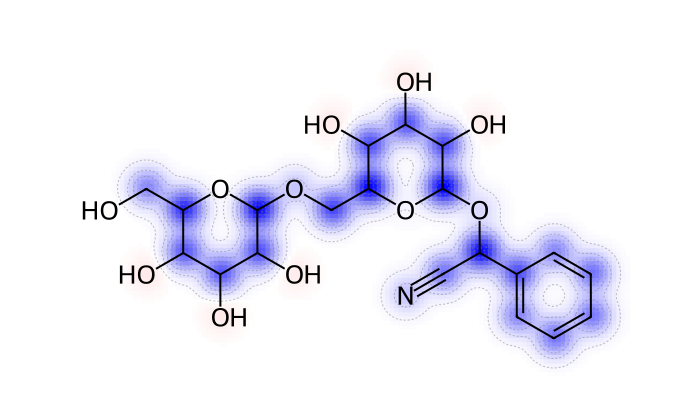

[ESOL|dataset item] IG 原子热图 | 标准预测 = -1.341658 | MC均值 = -1.339476 | 不确定度 = 0.008159
===== ESOL 回归结果 =====
SMILES： CCOCCc1cc(CC(=O)O)ccc1CO
标准预测值（eval）：-2.569034
MC-Dropout 均值：-2.617061
不确定度（MC 方差）：0.018984
IG 积分步数：64
MC-Dropout 采样次数：50


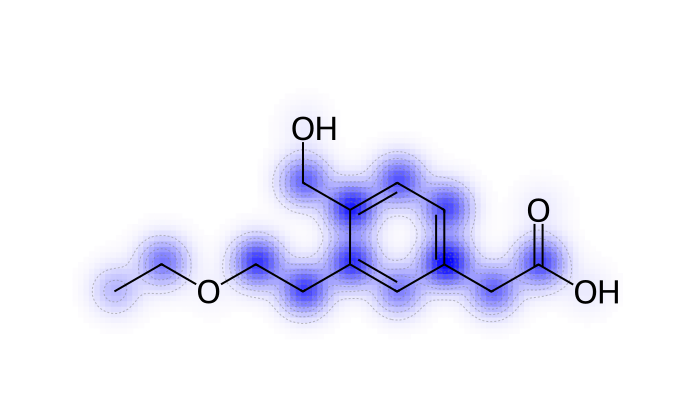

[ESOL|SMILES] IG 原子热图 | 标准预测 = -2.569034 | MC均值 = -2.617061 | 不确定度 = 0.018984


In [24]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.data import Data

from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import SVG, display
from torch_geometric.utils.smiles import from_smiles

rdDepictor.SetPreferCoordGen(True)


# =========================================================
# 0. 模型载入：与前文一致
# 需要你前文已经定义：
#   load_trained_model(task, dataset, cfg, device)
# =========================================================
def load_explainer_model_reg(dataset, cfg, device):
    cfg_local = copy.deepcopy(cfg)
    cfg_local["task"] = "reg"
    model, ckpt = load_trained_model("reg", dataset, cfg_local, device)
    model.eval()
    return model, ckpt


# =========================================================
# 1. 通用工具
# =========================================================
def _extract_main_output(out):
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


def _copy_data(data, new_x=None):
    new_data = Data()
    for k, v in data:
        new_data[k] = v
    if new_x is not None:
        new_data.x = new_x
    return new_data


def _ensure_batch(data):
    if (not hasattr(data, "batch")) or (data.batch is None):
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)
    return data


def _enable_dropout_only(model):
    """
    保持整体 eval，只把 Dropout 层切到 train。
    这样不会把 BatchNorm 一起切到训练态。
    """
    model.eval()
    dropout_types = (
        nn.Dropout,
        nn.Dropout1d,
        nn.Dropout2d,
        nn.Dropout3d,
        nn.AlphaDropout,
        nn.FeatureAlphaDropout,
    )
    for m in model.modules():
        if isinstance(m, dropout_types):
            m.train()


# =========================================================
# 2. SMILES -> PyG Data
# 仅适用于：训练时本来就使用了 PyG 的 from_smiles / 同构图方式
# 如果你的训练集不是这样构建的，就不要用它做“对照旧结果”
# =========================================================
def smiles_to_data_pyg(smiles, ref_dataset=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"RDKit 解析 SMILES 失败：{smiles}")

    data = from_smiles(smiles)
    data.smiles = smiles
    data = _ensure_batch(data)

    if ref_dataset is not None:
        ref = ref_dataset[0]

        if hasattr(ref, "x") and ref.x is not None:
            if data.x.size(-1) != ref.x.size(-1):
                raise ValueError(
                    f"x 维度不一致：当前分子 x_dim={data.x.size(-1)}，"
                    f"训练数据 x_dim={ref.x.size(-1)}"
                )
            if data.x.dtype != ref.x.dtype:
                data.x = data.x.to(ref.x.dtype)

        ref_has_edge_attr = hasattr(ref, "edge_attr") and ref.edge_attr is not None
        cur_has_edge_attr = hasattr(data, "edge_attr") and data.edge_attr is not None

        if ref_has_edge_attr != cur_has_edge_attr:
            raise ValueError("当前分子与训练数据在 edge_attr 是否存在这一点上不一致。")

        if ref_has_edge_attr and cur_has_edge_attr:
            if data.edge_attr.size(-1) != ref.edge_attr.size(-1):
                raise ValueError(
                    f"edge_attr 维度不一致：当前分子 edge_attr_dim={data.edge_attr.size(-1)}，"
                    f"训练数据 edge_attr_dim={ref.edge_attr.size(-1)}"
                )
            if data.edge_attr.dtype != ref.edge_attr.dtype:
                data.edge_attr = data.edge_attr.to(ref.edge_attr.dtype)

    return data


# =========================================================
# 3. 标准回归预测
# =========================================================
@torch.no_grad()
def predict_regression_deterministic(model, data):
    model.eval()
    out = model(data)
    out = _extract_main_output(out)
    return out.view(-1)


# =========================================================
# 4. MC-Dropout：回归预测与不确定度
# 注意：这里只打开 dropout，不打开整个 train()
# =========================================================
@torch.no_grad()
def mc_dropout_predict_regression(model, data, T=50):
    _enable_dropout_only(model)

    preds = []
    for _ in range(T):
        out = model(data)
        out = _extract_main_output(out)
        preds.append(out.view(-1).unsqueeze(0))

    preds = torch.cat(preds, dim=0)   # [T, B]
    mean_pred = preds.mean(dim=0)
    var_pred = preds.var(dim=0, unbiased=False)

    # 采样完成后恢复 eval
    model.eval()
    return mean_pred, var_pred


# =========================================================
# 5. IG：对节点特征 x 计算积分梯度
# =========================================================
def integrated_gradients_x_regression(model, data, steps=64, baseline=None):
    """
    对节点输入特征 x 做 Integrated Gradients。
    这里允许原始 x 不是 float，会先转成 float 后再做 IG。
    最终得到 attr: [N, F]，可在特征维上聚合为原子级重要性。
    """
    model.eval()
    device = next(model.parameters()).device
    data = _copy_data(data).to(device)

    # 直接转成 float，继续做 IG
    x0 = data.x.detach().float()

    if baseline is None:
        baseline = torch.zeros_like(x0)
    else:
        baseline = baseline.to(device).float()

    total_grad = torch.zeros_like(x0)

    for i in range(1, steps + 1):
        alpha = float(i) / steps
        xi = (baseline + alpha * (x0 - baseline)).detach()
        xi.requires_grad_(True)

        d_i = _copy_data(data, new_x=xi).to(device)
        out = model(d_i)
        out = _extract_main_output(out)
        score = out.view(-1)[0]

        model.zero_grad(set_to_none=True)
        if xi.grad is not None:
            xi.grad.zero_()

        score.backward()
        total_grad += xi.grad.detach()

    avg_grad = total_grad / steps
    attr = (x0 - baseline) * avg_grad
    return attr.detach()


# =========================================================
# 6. RDKit 热图显示
# =========================================================
def show_similarity_map(mol, weights_signed, title="", cmap_name="bwr"):
    w = np.asarray(weights_signed, dtype=float).reshape(-1)
    w = [float(x) for x in w.tolist()]

    d2d = Draw.MolDraw2DSVG(700, 420)
    d2d.drawOptions().useBWAtomPalette()

    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        w,
        d2d,
        colorMap=cmap_name,
        alpha=0
    )

    d2d.FinishDrawing()
    display(SVG(d2d.GetDrawingText()))

    if title:
        print(title)


# =========================================================
# 7. 单个 Data 图的解释
# 这是最稳妥的入口：直接吃已经构建好的 PyG Data
# =========================================================
def explain_one_data_esol(
    data,
    model,
    device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    title_prefix="[ESOL]",
):
    data = _copy_data(data)
    data = _ensure_batch(data).to(device)

    # ---- 标准预测 ----
    det_pred = predict_regression_deterministic(model, data)
    pred_value = float(det_pred.view(-1)[0].item())

    # ---- MC-Dropout ----
    mc_mean, mc_var = mc_dropout_predict_regression(model, data, T=T)
    mc_mean_value = float(mc_mean.view(-1)[0].item())
    uncertainty = float(mc_var.view(-1)[0].item())

    # ---- IG ----
    attr_x = None
    node_signed = None
    node_abs = None
    ig_error = None

    try:
        attr_x = integrated_gradients_x_regression(
            model=model,
            data=data,
            steps=steps,
            baseline=baseline
        )
        node_signed = attr_x.sum(dim=1).detach().cpu().numpy()
        node_abs = attr_x.abs().sum(dim=1).detach().cpu().numpy()
    except Exception as e:
        ig_error = str(e)

    # ---- 展示 ----
    smiles = getattr(data, "smiles", None)

    print("===== ESOL 回归结果 =====")
    if smiles is not None:
        print("SMILES：", smiles)
    print(f"标准预测值（eval）：{pred_value:.6f}")
    print(f"MC-Dropout 均值：{mc_mean_value:.6f}")
    print(f"不确定度（MC 方差）：{uncertainty:.6f}")

    if true_value is not None:
        print(f"真实 ESOL 数值：{true_value:.6f}")
        print(f"标准预测绝对误差：{abs(pred_value - true_value):.6f}")
        print(f"MC 均值绝对误差：{abs(mc_mean_value - true_value):.6f}")

    print(f"IG 积分步数：{steps}")
    print(f"MC-Dropout 采样次数：{T}")

    if ig_error is not None:
        print("IG 未执行：", ig_error)

    # ---- 画图 ----
    if (smiles is not None) and (node_signed is not None):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None and mol.GetNumAtoms() == len(node_signed):
            show_similarity_map(
                mol,
                node_signed,
                title=(
                    f"{title_prefix} IG 原子热图 | "
                    f"标准预测 = {pred_value:.6f} | "
                    f"MC均值 = {mc_mean_value:.6f} | "
                    f"不确定度 = {uncertainty:.6f}"
                )
            )
        else:
            print("未绘制热图：RDKit 分子与归因长度不一致。")

    return {
        "smiles": smiles,
        "pred_value": pred_value,          # 标准 eval 预测
        "mc_mean_value": mc_mean_value,    # MC-Dropout 均值
        "true_value": true_value,
        "uncertainty": uncertainty,
        "node_signed": node_signed,
        "node_abs": node_abs,
        "attr_x": None if attr_x is None else attr_x.detach().cpu().numpy(),
        "ig_error": ig_error,
    }


# =========================================================
# 8. 从数据集中取一个样本进行展示
# 关键修正：
# 直接使用 dataset[index] 原图，不再从 smiles 重建
# =========================================================
def explain_dataset_item_esol(
    dataset,
    index,
    cfg,
    device,
    T=50,
    steps=64,
    baseline=None,
    model=None,
):
    if model is None:
        model, ckpt = load_explainer_model_reg(dataset, cfg, device)

    item = dataset[index]

    true_value = None
    if hasattr(item, "y") and item.y is not None:
        true_value = float(item.y.view(-1)[0].item())

    return explain_one_data_esol(
        data=item,
        model=model,
        device=device,
        true_value=true_value,
        T=T,
        steps=steps,
        baseline=baseline,
        title_prefix="[ESOL|dataset item]",
    )


# =========================================================
# 9. 给定一个外部分子 SMILES 进行展示
# 注意：
# 只有当你的训练数据本来也是用同样的 PyG from_smiles 方式构图时，
# 这个函数得到的结果才有可比性。
# =========================================================
def explain_one_molecule_esol(
    smiles,
    ref_dataset,
    cfg,
    device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    model=None,
):
    if model is None:
        model, ckpt = load_explainer_model_reg(ref_dataset, cfg, device)

    data = smiles_to_data_pyg(smiles, ref_dataset=ref_dataset)

    return explain_one_data_esol(
        data=data,
        model=model,
        device=device,
        true_value=true_value,
        T=T,
        steps=steps,
        baseline=baseline,
        title_prefix="[ESOL|SMILES]",
    )


# =========================================================
# 10. 使用示例
# =========================================================
UQ_CFG = {
    "task": "reg",                
    "seed": 42,
    "batch_size_eval": 64,
    "hidden_dim": 128,
    "num_layers": 4,
    "dropout": 0.2,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "epochs": 100,
    "model_dir": "saved_models",
    "mc_T": 100,
    "eval_split": "test"
}

# ---------- 先统一载入一次模型 ----------
model_reg_loaded, reg_ckpt = load_explainer_model_reg(ds_reg, UQ_CFG, device)

# ---------- 示例1：解释数据集中的某个样本 ----------
result_dataset = explain_dataset_item_esol(
    dataset=ds_reg,
    index=0,
    cfg=UQ_CFG,
    device=device,
    T=50,
    steps=64,
    baseline=None,
    model=model_reg_loaded,
)

print("=========================================================")

# ---------- 示例2：解释一个外部 SMILES ----------
# 仅在训练集本来也是用同样 PyG 构图方式时再用它
result_smiles = explain_one_molecule_esol(
    smiles="CCOCCc1cc(CC(=O)O)ccc1CO",
    ref_dataset=ds_reg,
    cfg=UQ_CFG,
    device=device,
    true_value=None,
    T=50,
    steps=64,
    baseline=None,
    model=model_reg_loaded,
)